In [75]:
import pandas as pd
import matplotlib.pyplot as plt

In [76]:
df_data = pd.read_csv('datasets/opentender_clean_2022_2024.csv')

In [77]:
df_data.head()

,ocid,buyer_name,vendor_name,HPS,contract_value,procurement_method,category,item_description,date
0,ocds-20h3g7-12482010,Pemerintah Daerah Kota Surabaya,PT. DUTA BHUANA JAYA,7.445028e+08,6.666604e+08,consultancyServices,services,Jasa Konsultansi Badan Usaha Konstruksi,2024-02-02
1,ocds-20h3g7-12487010,Pemerintah Daerah Kota Surabaya,"MARGA PERKASA,CV",4.793422e+09,4.129909e+09,NaN,works,Pekerjaan Konstruksi,2024-01-15
2,ocds-20h3g7-12492010,Pemerintah Daerah Kota Surabaya,CV. Naga Kencana Wiratama,2.255991e+09,2.012700e+09,NaN,works,Pekerjaan Konstruksi,2024-01-15
3,ocds-20h3g7-12496010,Pemerintah Daerah Kota Surabaya,CV. Tiga Points Jaya Karya,3.425503e+09,2.566207e+09,NaN,works,Pekerjaan Konstruksi,2024-01-16
4,ocds-20h3g7-12504010,Pemerintah Daerah Kota Surabaya,CV. Citra Karya,1.307263e+09,1.231890e+09,NaN,works,Pekerjaan Konstruksi,2024-01-15


In [78]:
df_data.head()
df_data.info()
df_data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 292852 entries, 0 to 292851
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ocid                292852 non-null  str    
 1   buyer_name          288191 non-null  str    
 2   vendor_name         164113 non-null  str    
 3   HPS                 163738 non-null  float64
 4   contract_value      164113 non-null  float64
 5   procurement_method  26328 non-null   str    
 6   category            164113 non-null  str    
 7   item_description    164113 non-null  str    
 8   date                292852 non-null  str    
dtypes: float64(2), str(7)
memory usage: 48.0 MB


,HPS,contract_value
count,1.637380e+05,1.641130e+05
mean,3.817390e+09,3.529409e+09
std,3.461689e+10,3.307242e+10
min,1.760000e+04,1.050000e+04
25%,3.795271e+08,3.504016e+08
50%,6.947567e+08,6.399824e+08
75%,1.800000e+09,1.660123e+09
max,4.286669e+12,4.242926e+12


## EXPLORATORY DATA ANALYSIS (EDA)

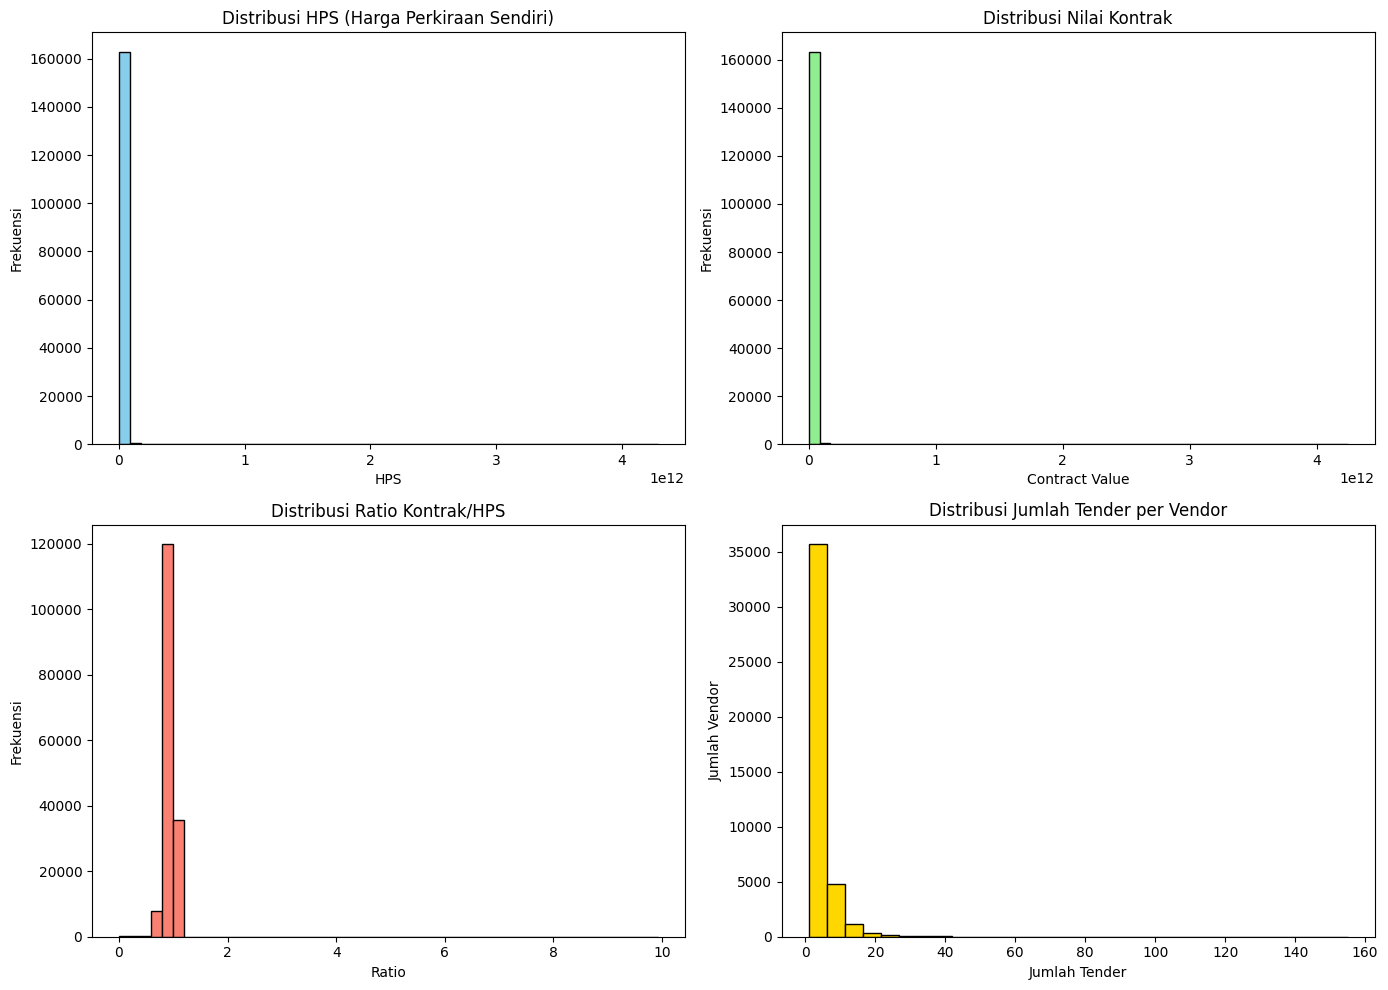

Distribution Analysis Selesai



In [79]:
import seaborn as sns

# 1. DISTRIBUTION PLOTS - KEY NUMERICAL FEATURES
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# HPS Distribution
axes[0, 0].hist(df_data['HPS'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribusi HPS (Harga Perkiraan Sendiri)', fontsize=12)
axes[0, 0].set_xlabel('HPS')
axes[0, 0].set_ylabel('Frekuensi')

# Contract Value Distribution
axes[0, 1].hist(df_data['contract_value'], bins=50, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Distribusi Nilai Kontrak', fontsize=12)
axes[0, 1].set_xlabel('Contract Value')
axes[0, 1].set_ylabel('Frekuensi')

# Discount Percentage Distribution (after feature engineering, using ratio as proxy)
axes[1, 0].hist(df_data['contract_value'] / df_data['HPS'], bins=50, color='salmon', edgecolor='black')
axes[1, 0].set_title('Distribusi Ratio Kontrak/HPS', fontsize=12)
axes[1, 0].set_xlabel('Ratio')
axes[1, 0].set_ylabel('Frekuensi')

# Vendor count distribution
vendor_counts = df_data['vendor_name'].value_counts()
axes[1, 1].hist(vendor_counts.values, bins=30, color='gold', edgecolor='black')
axes[1, 1].set_title('Distribusi Jumlah Tender per Vendor', fontsize=12)
axes[1, 1].set_xlabel('Jumlah Tender')
axes[1, 1].set_ylabel('Jumlah Vendor')

plt.tight_layout()
plt.show()

print("Distribution Analysis Selesai\n")

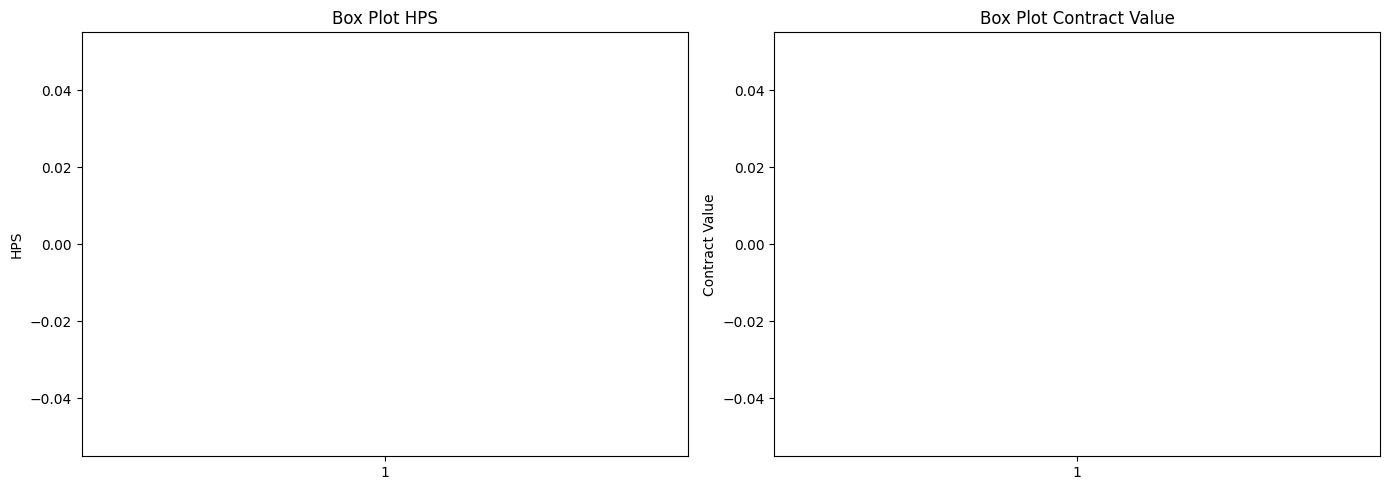

Box Plot Analysis Selesai



In [80]:
# 2. BOX PLOTS - DETEKSI OUTLIERS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot HPS
axes[0].boxplot(df_data['HPS'])
axes[0].set_title('Box Plot HPS', fontsize=12)
axes[0].set_ylabel('HPS')

# Box plot Contract Value
axes[1].boxplot(df_data['contract_value'])
axes[1].set_title('Box Plot Contract Value', fontsize=12)
axes[1].set_ylabel('Contract Value')

plt.tight_layout()
plt.show()

print("Box Plot Analysis Selesai\n")

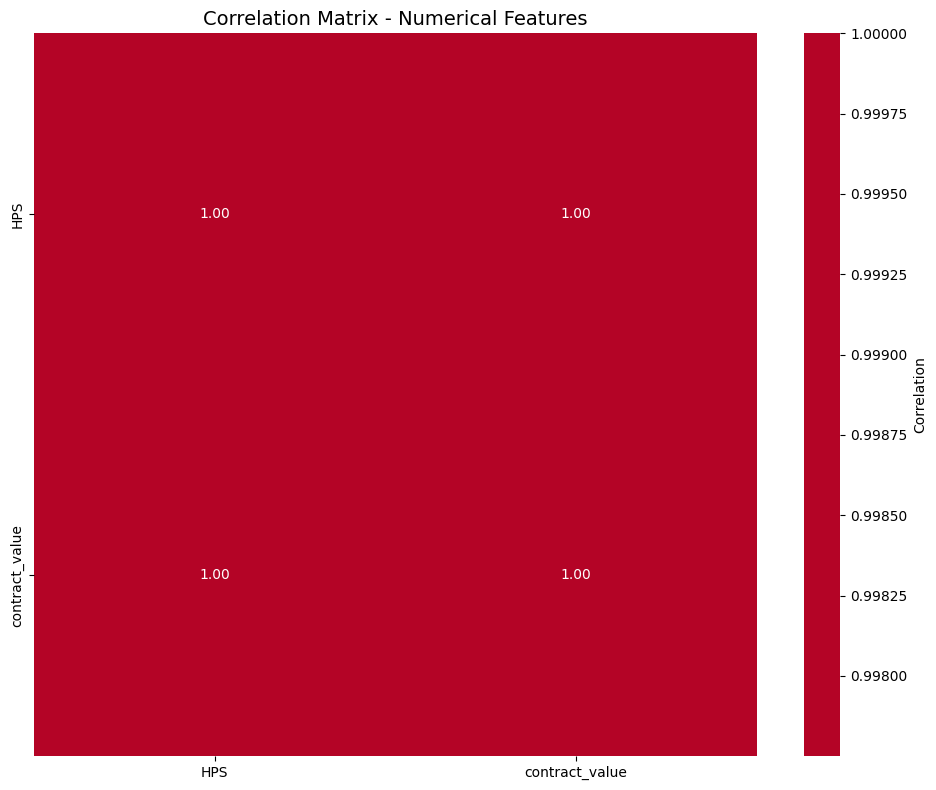

Correlation Analysis Selesai



In [81]:
# 3. CORRELATION ANALYSIS - NUMERICAL FEATURES
numerical_cols = df_data.select_dtypes(include=['float64', 'int64']).columns

# Hitung correlation hanya untuk kolom yang valid
numeric_df = df_data[numerical_cols].dropna()

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    square=True,
    cbar_kws={'label': 'Correlation'}
)
plt.title('Correlation Matrix - Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

print("Correlation Analysis Selesai\n")

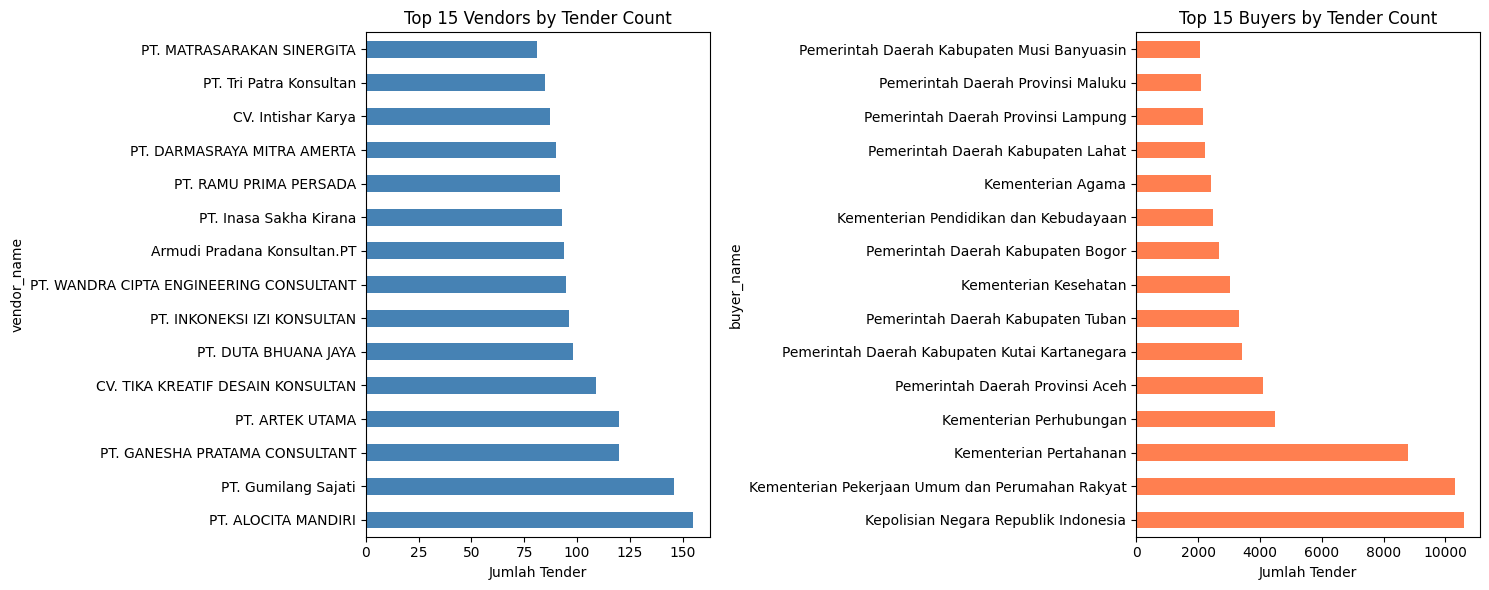

Vendor & Buyer Analysis Selesai



In [82]:
# 4. TOP VENDORS & BUYERS ANALYSIS
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 15 Vendors by Count
top_vendors = df_data['vendor_name'].value_counts().head(15)
top_vendors.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Vendors by Tender Count', fontsize=12)
axes[0].set_xlabel('Jumlah Tender')

# Top 15 Buyers by Count
top_buyers = df_data['buyer_name'].value_counts().head(15)
top_buyers.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 15 Buyers by Tender Count', fontsize=12)
axes[1].set_xlabel('Jumlah Tender')

plt.tight_layout()
plt.show()

print("Vendor & Buyer Analysis Selesai\n")

*CLEANING NOISE*

In [83]:
df_data = df_data.drop(columns=["procurement_method"])
#kudrop noise tinggi

In [84]:
df_data = df_data.dropna(subset=[
    "vendor_name",
    "contract_value"
])

In [85]:
df_data = df_data.dropna(subset=["HPS"])

In [86]:
df_data = df_data.dropna(subset=["buyer_name"])

In [87]:
df_data = df_data[df_data["HPS"] > 0]
df_data = df_data[df_data["contract_value"] > 0]

FEATURE ENGINEERING

rasio kontrak

In [88]:
#Rasio kontrak terhadap HPS
df_data["ratio"] = df_data["contract_value"] / df_data["HPS"]

In [89]:
#B. DISCOUNT PERCENTAGE
df_data["discount_percentage"] = (
    (df_data["HPS"] - df_data["contract_value"])
    / df_data["HPS"]
) * 100

In [90]:
# C. VENDOR WIN COUNT
# Berapa kali vendor menang tender

vendor_win_count = (
    df_data.groupby("vendor_name")
    .size()
    .reset_index(name="vendor_win_count")
)
# merge ke dataframe utama
df_data = df_data.merge(
    vendor_win_count,
    on="vendor_name",
    how="left"
)


In [91]:
# D. VENDOR-INSTANSI FREQUENCY
# Seberapa sering vendor menang di instansi tertentu

vendor_instansi_frequency = (
    df_data.groupby(["vendor_name", "buyer_name"])
    .size()
    .reset_index(name="vendor_instansi_frequency")
)

# merge kembali
df_data = df_data.merge(
    vendor_instansi_frequency,
    on=["vendor_name", "buyer_name"],
    how="left"
)

In [92]:
# E. AVERAGE VENDOR RATIO
# Rata-rata ratio tiap vendor

avg_vendor_ratio = (
    df_data.groupby("vendor_name")["ratio"]
    .mean()
    .reset_index(name="avg_vendor_ratio")
)

# merge kembali
df_data = df_data.merge(
    avg_vendor_ratio,
    on="vendor_name",
    how="left"
)

In [93]:
# OPTIONAL: ROUND AGAR RAPI

df_data["ratio"] = df_data["ratio"].round(4)

df_data["discount_percentage"] = (
    df_data["discount_percentage"].round(2)
)

df_data["avg_vendor_ratio"] = (
    df_data["avg_vendor_ratio"].round(4)
)

In [94]:
# CEK HASIL FEATURE ENGINEERING

print("Feature engineering selesai.\n")

print(df_data[
    [
        "vendor_name",
        "buyer_name",
        "HPS",
        "contract_value",
        "ratio",
        "discount_percentage",
        "vendor_win_count",
        "vendor_instansi_frequency",
        "avg_vendor_ratio"
    ]
].head())

# SAVE FEATURED DATASET

df_data.to_csv(
    "featured_procurement_dataset.csv",
    index=False
)

print("\nDataset berhasil disimpan.")

Feature engineering selesai.

                  vendor_name                       buyer_name           HPS  \
0        PT. DUTA BHUANA JAYA  Pemerintah Daerah Kota Surabaya  7.445028e+08   
1            MARGA PERKASA,CV  Pemerintah Daerah Kota Surabaya  4.793422e+09   
2   CV. Naga Kencana Wiratama  Pemerintah Daerah Kota Surabaya  2.255991e+09   
3  CV. Tiga Points Jaya Karya  Pemerintah Daerah Kota Surabaya  3.425503e+09   
4             CV. Citra Karya  Pemerintah Daerah Kota Surabaya  1.307263e+09   

   contract_value   ratio  discount_percentage  vendor_win_count  \
0    6.666604e+08  0.8954                10.46                97   
1    4.129909e+09  0.8616                13.84                 2   
2    2.012700e+09  0.8922                10.78                 3   
3    2.566207e+09  0.7491                25.09                 1   
4    1.231890e+09  0.9423                 5.77                 1   

   vendor_instansi_frequency  avg_vendor_ratio  
0                          6   

In [95]:
print(df_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 161422 entries, 0 to 161421
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ocid                       161422 non-null  str    
 1   buyer_name                 161422 non-null  str    
 2   vendor_name                161422 non-null  str    
 3   HPS                        161422 non-null  float64
 4   contract_value             161422 non-null  float64
 5   category                   161422 non-null  str    
 6   item_description           161422 non-null  str    
 7   date                       161422 non-null  str    
 8   ratio                      161422 non-null  float64
 9   discount_percentage        161422 non-null  float64
 10  vendor_win_count           161422 non-null  int64  
 11  vendor_instansi_frequency  161422 non-null  int64  
 12  avg_vendor_ratio           161422 non-null  float64
dtypes: float64(5), int64(2), str(6)
memory u

**ISOLATION FOREST**

In [96]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [97]:
features = [
    "HPS",
    "contract_value",
    "ratio",
    "discount_percentage",
    "vendor_win_count",
    "vendor_instansi_frequency",
    "avg_vendor_ratio"
]

X = df_data[features]

In [98]:
X = X.dropna()

In [99]:
df_model = df_data.loc[X.index].copy()

In [100]:
df_model = df_data.loc[X.index].copy()

parameter

In [101]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [102]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)

FIT MODEL

In [103]:
iso_forest.fit(X_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [104]:
df_model["anomaly_label"] = iso_forest.predict(X_scaled)

In [105]:
df_model["anomaly_score"] = (
    iso_forest.decision_function(X_scaled)
)

In [106]:
top_anomalies = df_model.sort_values(
    by="anomaly_score"
).head(20)

In [107]:
print(top_anomalies[
    [
        "vendor_name",
        "buyer_name",
        "HPS",
        "contract_value",
        "ratio",
        "discount_percentage",
        "vendor_win_count",
        "anomaly_score"
    ]
])

                                     vendor_name  \
56104              PT BRANTAS ABIPRAYA (Persero)   
74555              PT BRANTAS ABIPRAYA (Persero)   
74429              PT BRANTAS ABIPRAYA (Persero)   
19847              PT BRANTAS ABIPRAYA (Persero)   
37721              PT BRANTAS ABIPRAYA (Persero)   
95543              PT BRANTAS ABIPRAYA (Persero)   
99362                          SAPTA KARYA ABADI   
74557            PT. WASKITA KARYA (PERSERO) Tbk   
95512            PT. WASKITA KARYA (PERSERO) Tbk   
38178   PT. Pembangunan Perumahan (Persero)  Tbk   
19684            PT. WASKITA KARYA (PERSERO) Tbk   
37893   PT. Pembangunan Perumahan (Persero)  Tbk   
38105              PT BRANTAS ABIPRAYA (Persero)   
117038  PT. Pembangunan Perumahan (Persero)  Tbk   
74790   PT. Pembangunan Perumahan (Persero)  Tbk   
138575  PT. Pembangunan Perumahan (Persero)  Tbk   
74831   PT. Pembangunan Perumahan (Persero)  Tbk   
74430                 PT. NINDYA KARYA (Persero)   
19821   PT. 

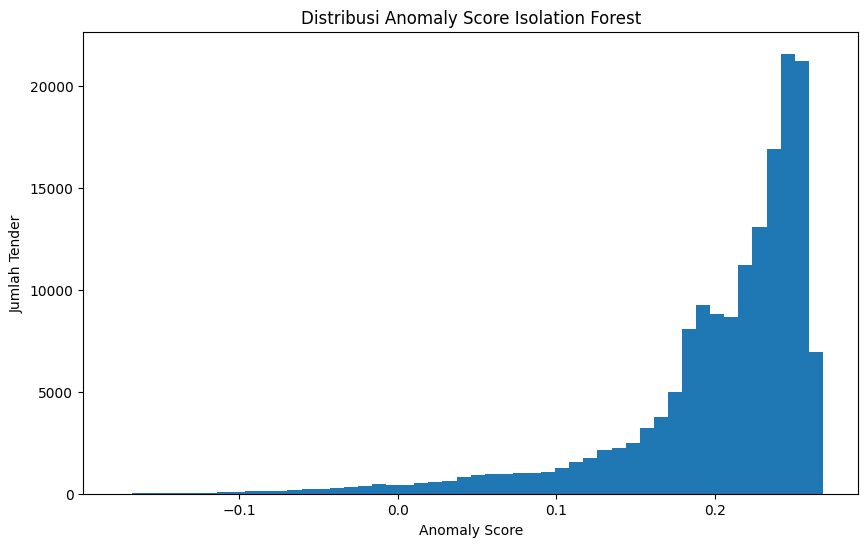

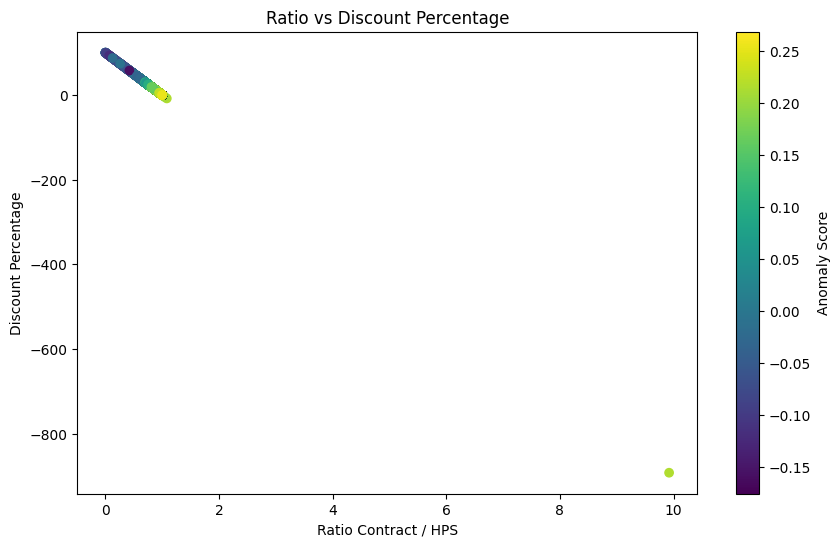

TOP SUSPICIOUS VENDORS
vendor_name
Firma KJSB Subkhi Abdul Hakim At Tigholy dan Rekan   -0.158629
PT. ENSEVAL PUTERA MEGATRADING. Tbk                  -0.151866
PT.BIOGEN SCIENTIFIC                                 -0.149281
PT. ENSEVAL PUTERA MEGATRADING, Tbk                  -0.147734
PT BRANTAS ABIPRAYA (Persero)                        -0.141380
PT. Pembangunan Perumahan (Persero)  Tbk             -0.139737
PT. WASKITA KARYA (PERSERO) Tbk                      -0.131909
PT ADHI KARYA (Persero) Tbk                          -0.123318
Admiral Blesensa Abadi                               -0.121421
PT. MITRA FAJAR SELARAS                              -0.119931
Name: anomaly_score, dtype: float64


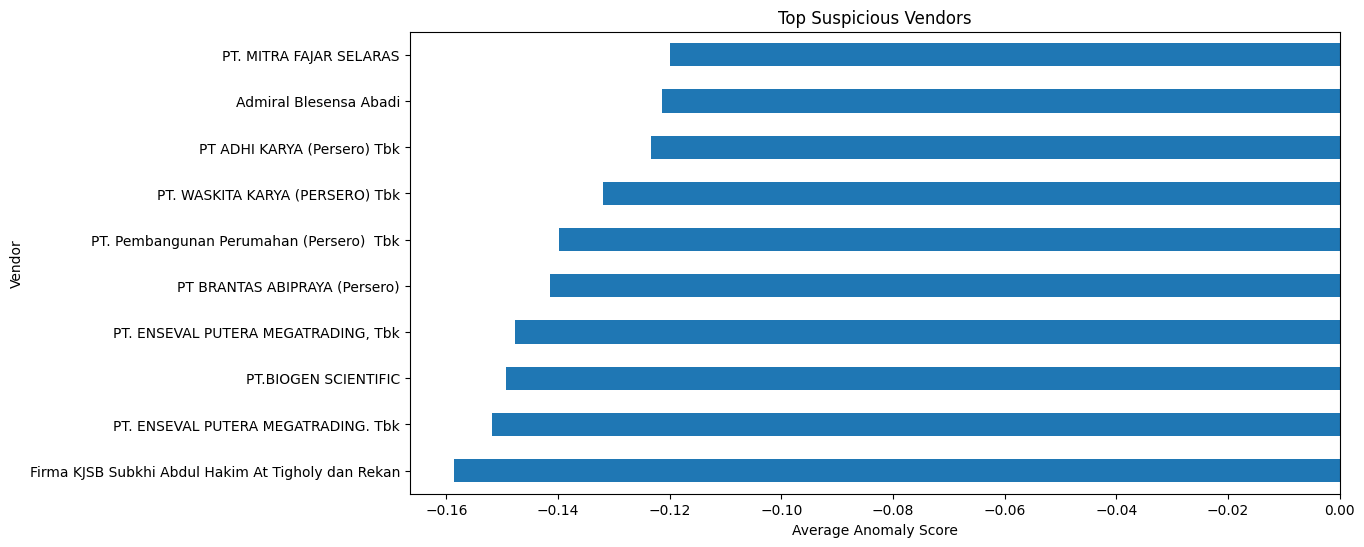

INSTANSI PALING RAWAN

buyer_name
PDAM Delta Tirta Sidoarjo                                   0.049226
PD BKK Kesugihan Kabupaten Cilacap                          0.049560
Badan Pusat Statistik                                       0.062621
Lembaga Perlindungan Saksi dan Korban Republik Indonesia    0.067784
Kementerian Pekerjaan Umum dan Perumahan Rakyat             0.084821
Pemerintah Daerah Kota Denpasar                             0.091077
Pemerintah Daerah Kabupaten Jayawijaya                      0.092993
PDAM Kabupaten Semarang                                     0.095726
PDAM Tirtamarta Yogyakarta                                  0.098016
Kejaksaan Republik Indonesia                                0.103440
Name: anomaly_score, dtype: float64


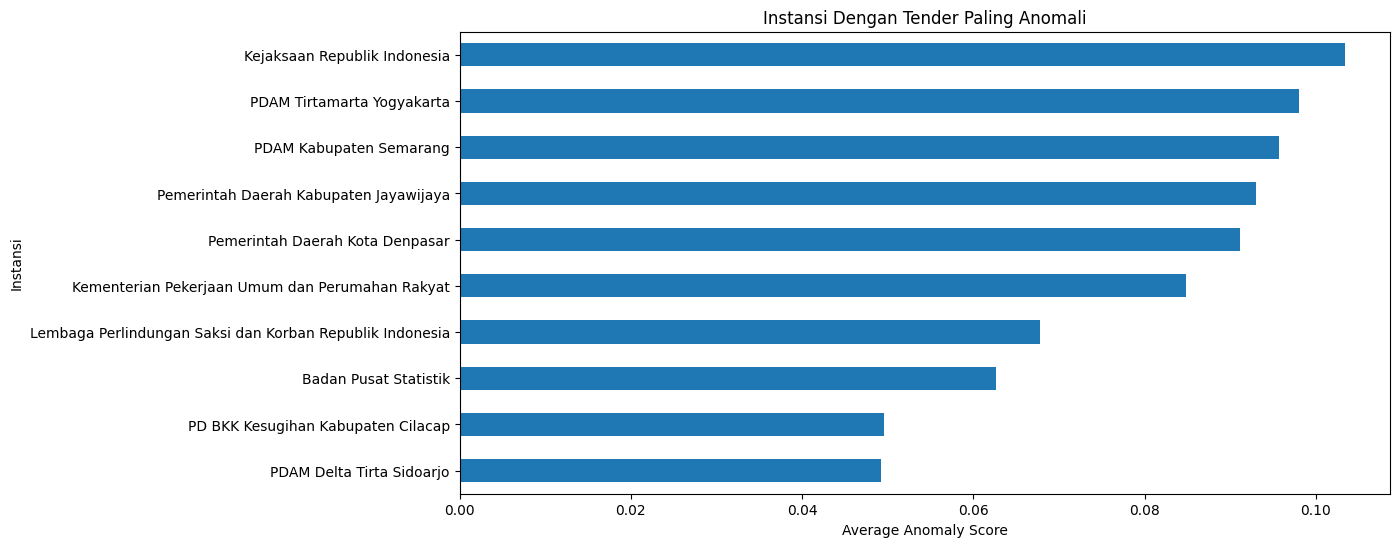

VENDOR DOMINANCE

vendor_name
PT. ALOCITA MANDIRI                        153
PT. Gumilang Sajati                        143
PT. ARTEK UTAMA                            120
PT. GANESHA PRATAMA CONSULTANT             116
CV. TIKA KREATIF DESAIN KONSULTAN          109
PT. DUTA BHUANA JAYA                        97
PT. WANDRA CIPTA ENGINEERING CONSULTANT     94
PT. INKONEKSI IZI KONSULTAN                 92
PT. Inasa Sakha Kirana                      91
PT. DARMASRAYA MITRA AMERTA                 90
Name: count, dtype: int64


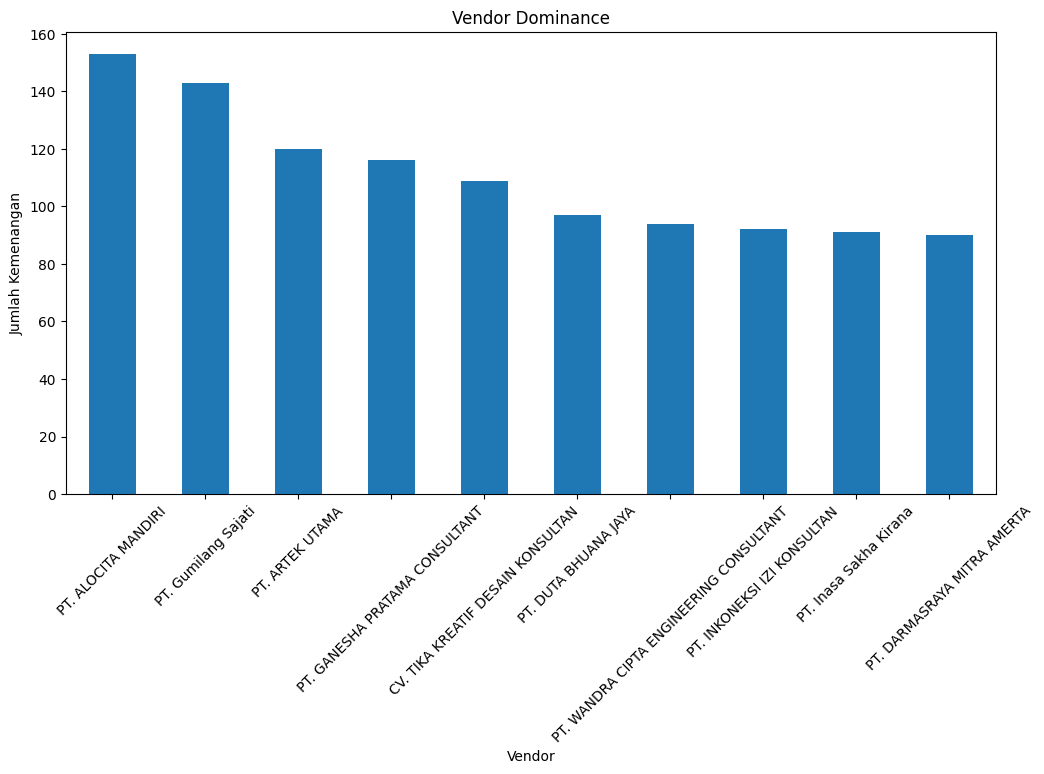

TOP 20 MOST SUSPICIOUS TENDERS

                                     vendor_name  \
56104              PT BRANTAS ABIPRAYA (Persero)   
74555              PT BRANTAS ABIPRAYA (Persero)   
74429              PT BRANTAS ABIPRAYA (Persero)   
19847              PT BRANTAS ABIPRAYA (Persero)   
37721              PT BRANTAS ABIPRAYA (Persero)   
95543              PT BRANTAS ABIPRAYA (Persero)   
99362                          SAPTA KARYA ABADI   
74557            PT. WASKITA KARYA (PERSERO) Tbk   
95512            PT. WASKITA KARYA (PERSERO) Tbk   
38178   PT. Pembangunan Perumahan (Persero)  Tbk   
19684            PT. WASKITA KARYA (PERSERO) Tbk   
37893   PT. Pembangunan Perumahan (Persero)  Tbk   
38105              PT BRANTAS ABIPRAYA (Persero)   
117038  PT. Pembangunan Perumahan (Persero)  Tbk   
74790   PT. Pembangunan Perumahan (Persero)  Tbk   
138575  PT. Pembangunan Perumahan (Persero)  Tbk   
74831   PT. Pembangunan Perumahan (Persero)  Tbk   
74430                 PT. NINDYA

In [108]:
# VISUALIZATION & DASHBOARD
# Isolation Forest Fraud Detection

import pandas as pd
import matplotlib.pyplot as plt

# 1. HISTOGRAM ANOMALY SCORE

plt.figure(figsize=(10,6))

plt.hist(
    df_model["anomaly_score"],
    bins=50
)

plt.xlabel("Anomaly Score")
plt.ylabel("Jumlah Tender")
plt.title("Distribusi Anomaly Score Isolation Forest")

plt.show()

# 2. SCATTER PLOT
# Ratio vs Discount Percentage

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df_model["ratio"],
    df_model["discount_percentage"],
    c=df_model["anomaly_score"]
)

plt.xlabel("Ratio Contract / HPS")
plt.ylabel("Discount Percentage")
plt.title("Ratio vs Discount Percentage")

plt.colorbar(scatter, label="Anomaly Score")

plt.show()

# 3. TOP SUSPICIOUS VENDORS

top_suspicious_vendors = (
    df_model.groupby("vendor_name")["anomaly_score"]
    .mean()
    .sort_values()
    .head(10)
)

print("TOP SUSPICIOUS VENDORS")
print(top_suspicious_vendors)

# VISUALISASI TOP SUSPICIOUS VENDORS

plt.figure(figsize=(12,6))

top_suspicious_vendors.plot(kind="barh")

plt.xlabel("Average Anomaly Score")
plt.ylabel("Vendor")
plt.title("Top Suspicious Vendors")

plt.show()

# 4. INSTANSI RAWAN

risky_agencies = (
    df_model.groupby("buyer_name")["anomaly_score"]
    .mean()
    .sort_values()
    .head(10)
)

print("INSTANSI PALING RAWAN\n")

print(risky_agencies)

# VISUALISASI INSTANSI RAWAN

plt.figure(figsize=(12,6))

risky_agencies.plot(kind="barh")

plt.xlabel("Average Anomaly Score")
plt.ylabel("Instansi")
plt.title("Instansi Dengan Tender Paling Anomali")

plt.show()

# 5. VENDOR DOMINANCE

vendor_dominance = (
    df_model["vendor_name"]
    .value_counts()
    .head(10)
)
print("VENDOR DOMINANCE\n")

print(vendor_dominance)

# VISUALISASI VENDOR DOMINANCE

plt.figure(figsize=(12,6))

vendor_dominance.plot(kind="bar")

plt.xlabel("Vendor")
plt.ylabel("Jumlah Kemenangan")
plt.title("Vendor Dominance")

plt.xticks(rotation=45)

plt.show()

# 6. TOP ANOMALY TABLE
top_anomalies = df_model.sort_values(
    by="anomaly_score"
).head(20)

print("TOP 20 MOST SUSPICIOUS TENDERS\n")

print(
    top_anomalies[
        [
            "vendor_name",
            "buyer_name",
            "HPS",
            "contract_value",
            "ratio",
            "discount_percentage",
            "vendor_win_count",
            "anomaly_score"
        ]
    ]
)
# OPTIONAL SAVE
top_anomalies.to_csv(
    "top_suspicious_tenders.csv",
    index=False
)

print("\nDashboard & visualisasi selesai.")

## D. GRAPH ANALYSIS - ADVANCED FRAUD DETECTION
Deteksi pola fraud kompleks: Kartel, Bid Rotation, dan Relasi Vendor

### 1. CARTEL DETECTION - Pola Kolaborasi Vendor Mencurigakan

### 2. BID ROTATION DETECTION - Pola Pergantian Vendor Sistematis

### 3. VENDOR RELATIONSHIP NETWORK - Visualisasi Relasi Vendor dan Buyer

### 4. VENDOR-BUYER RELATIONSHIP HEATMAP - Analisis Intensitas Relasi

## GRAPH ANALYSIS SUMMARY

In [111]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import Counter

In [112]:
#1.Building the graph vendor biparitee graph
# Buat bipartite graph vendor <-> instansi
G = nx.Graph()

for _, row in df_data.iterrows():
    vendor = f"V: {row['vendor_name']}"
    buyer  = f"B: {row['buyer_name']}"

    G.add_node(vendor, node_type="vendor")
    G.add_node(buyer,  node_type="buyer")

    if G.has_edge(vendor, buyer):
        G[vendor][buyer]["weight"] += 1
        G[vendor][buyer]["total_value"] += row["contract_value"]
    else:
        G.add_edge(
            vendor, buyer,
            weight=1,
            total_value=row["contract_value"]
        )

print(f"Nodes : {G.number_of_nodes()}")
print(f"Edges : {G.number_of_edges()}")

Nodes : 42687
Edges : 78382


Visual Nodes : 6655
Visual Edges : 6769


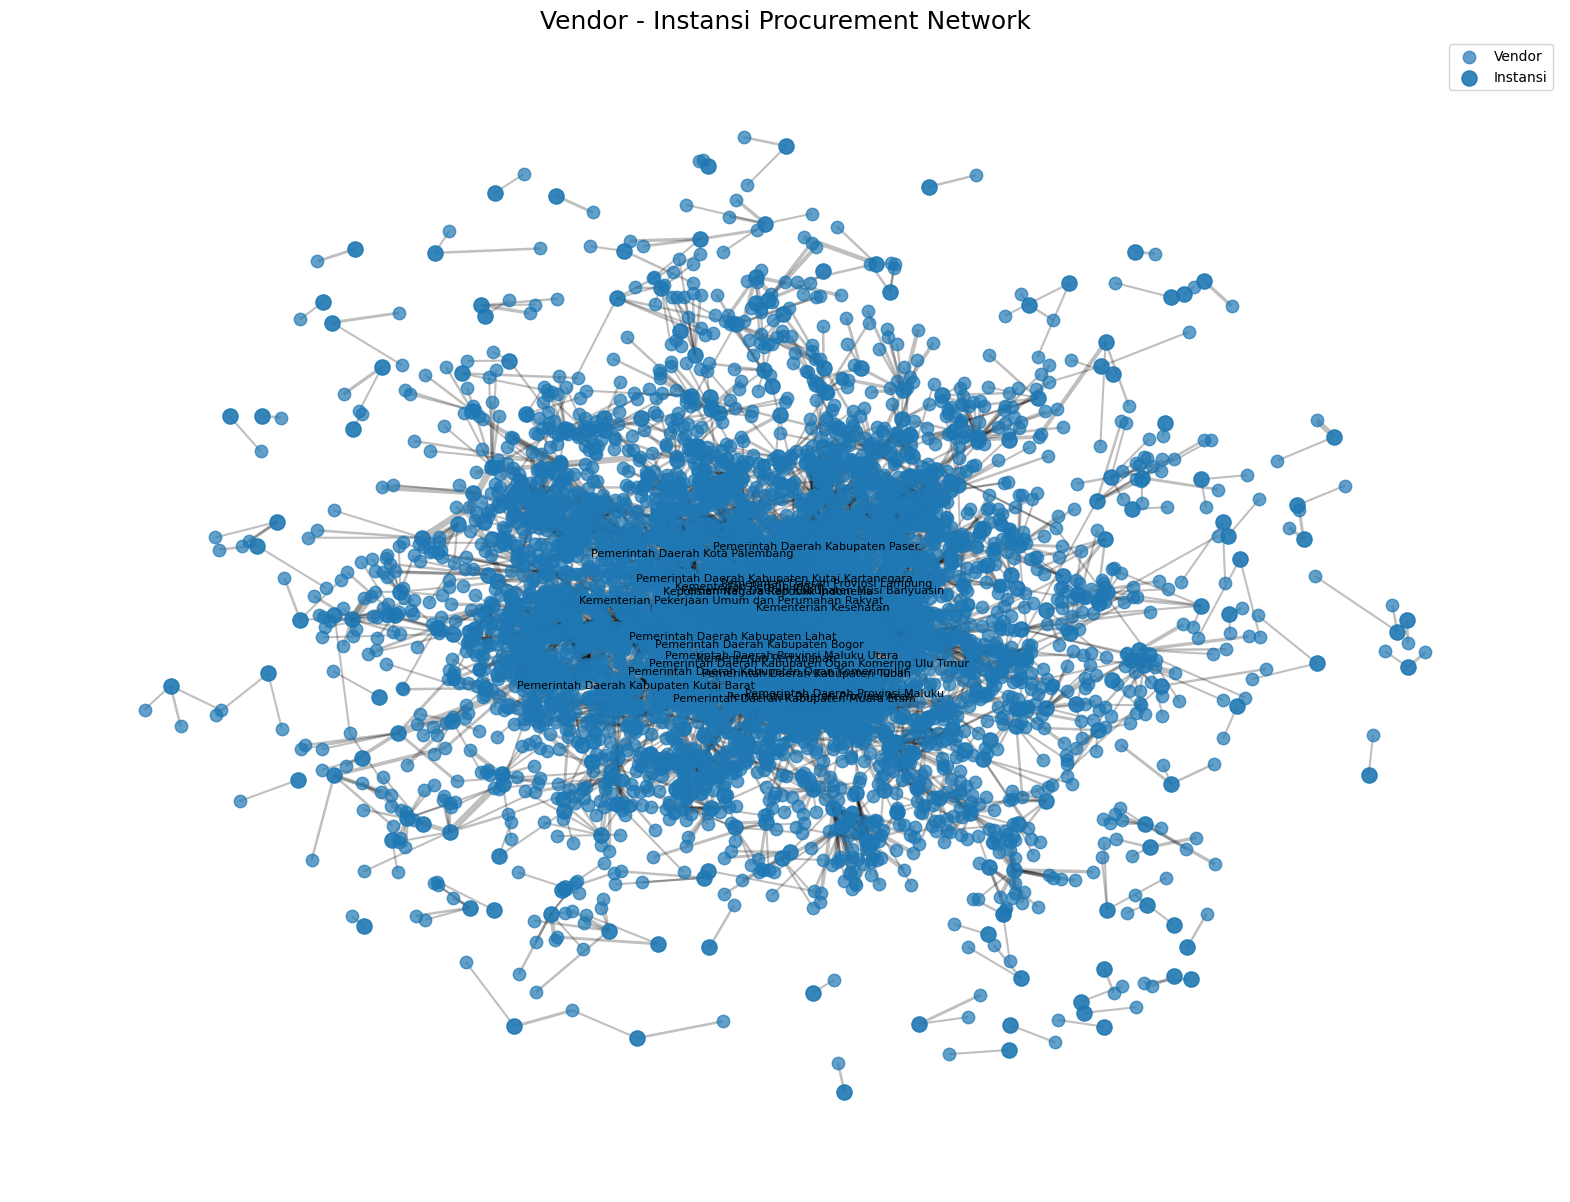

In [113]:
# =========================================================
# GRAPH ANALYSIS VISUALIZATION
# =========================================================

import matplotlib.pyplot as plt
import networkx as nx

# =========================================================
# FILTER GRAPH AGAR TIDAK TERLALU BESAR
# =========================================================
# Ambil edge dengan hubungan kuat saja
# misalnya vendor menang >= 5 kali
# =========================================================

filtered_edges = [
    (u, v, d)
    for u, v, d in G.edges(data=True)
    if d["weight"] >= 5
]

# =========================================================
# BUAT GRAPH BARU UNTUK VISUALISASI
# =========================================================

G_vis = nx.Graph()

for u, v, d in filtered_edges:
    G_vis.add_edge(
        u,
        v,
        weight=d["weight"],
        total_value=d["total_value"]
    )

print(f"Visual Nodes : {G_vis.number_of_nodes()}")
print(f"Visual Edges : {G_vis.number_of_edges()}")

# =========================================================
# POSISI NODE
# =========================================================

plt.figure(figsize=(20, 15))

pos = nx.spring_layout(
    G_vis,
    k=0.25,
    seed=42
)

# =========================================================
# PISAHKAN NODE
# =========================================================

vendor_nodes = [
    node for node, attr in G_vis.nodes(data=True)
    if attr.get("node_type") == "vendor"
    or str(node).startswith("V:")
]

buyer_nodes = [
    node for node, attr in G_vis.nodes(data=True)
    if attr.get("node_type") == "buyer"
    or str(node).startswith("B:")
]

# =========================================================
# UKURAN EDGE BERDASARKAN WEIGHT
# =========================================================

edge_widths = [
    G_vis[u][v]["weight"] * 0.3
    for u, v in G_vis.edges()
]

# =========================================================
# DRAW NODES
# =========================================================

nx.draw_networkx_nodes(
    G_vis,
    pos,
    nodelist=vendor_nodes,
    node_size=80,
    alpha=0.7,
    label="Vendor"
)

nx.draw_networkx_nodes(
    G_vis,
    pos,
    nodelist=buyer_nodes,
    node_size=120,
    alpha=0.9,
    label="Instansi"
)

# =========================================================
# DRAW EDGES
# =========================================================

nx.draw_networkx_edges(
    G_vis,
    pos,
    width=edge_widths,
    alpha=0.25
)

# =========================================================
# LABEL NODE PENTING SAJA
# =========================================================

degree_dict = dict(G_vis.degree())

top_nodes = sorted(
    degree_dict,
    key=degree_dict.get,
    reverse=True
)[:20]

labels = {
    node: node.replace("V: ", "").replace("B: ", "")
    for node in top_nodes
}

nx.draw_networkx_labels(
    G_vis,
    pos,
    labels,
    font_size=8
)

# =========================================================
# TITLE
# =========================================================

plt.title(
    "Vendor - Instansi Procurement Network",
    fontsize=18
)

plt.legend()

plt.axis("off")

plt.show()


VENDOR EKSKLUSIF (hanya menang di 1 instansi): 26683 vendor
                                   vendor_name                                      buyer_name  win_count  total_value
                         PT SARANA NIKITA JAYA                          Kementerian Pertahanan         49 3.282880e+11
KOPERASI KONSUMEN PUSAT KOPERASI KARTIKA TIDAR                          Kementerian Pertahanan         41 5.830011e+10
                      PT Timur Terang Samudera            Kepolisian Negara Republik Indonesia         36 4.407630e+10
                  PT. SCALARINDO UTAMA CONSULT                         Kementerian Perhubungan         35 6.251711e+10
                 PT. Wahana Transport Logistik            Kepolisian Negara Republik Indonesia         30 1.905557e+10
                   PT. Jakarta Rencana Selaras Kementerian Pekerjaan Umum dan Perumahan Rakyat         29 4.962763e+10
                       PT. Lautan Platina Raya                          Kementerian Pertahanan         29 

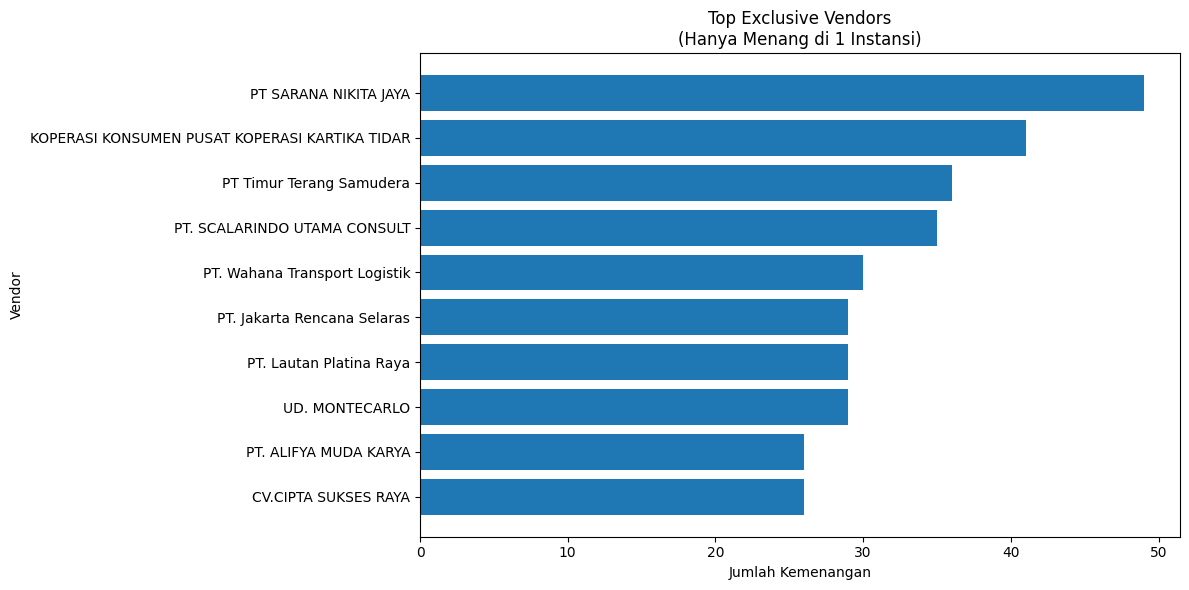

In [114]:
# ============================================================
# 3. DETEKSI VENDOR EKSKLUSIF (hanya menang di 1 instansi)
# ============================================================

vendor_nodes = [n for n in G.nodes if n.startswith("V:")]

exclusive_vendors = []
for v in vendor_nodes:
    neighbors = list(G.neighbors(v))
    if len(neighbors) == 1:
        buyer     = neighbors[0]
        freq      = G[v][buyer]["weight"]
        total_val = G[v][buyer]["total_value"]
        exclusive_vendors.append({
            "vendor_name" : v.replace("V: ", ""),
            "buyer_name"  : buyer.replace("B: ", ""),
            "win_count"   : freq,
            "total_value" : total_val
        })

exclusive_df = pd.DataFrame(exclusive_vendors).sort_values("win_count", ascending=False)

print(f"\nVENDOR EKSKLUSIF (hanya menang di 1 instansi): {len(exclusive_df)} vendor")
print(exclusive_df.head(10).to_string(index=False))
# ============================================================
# VISUALISASI VENDOR EKSKLUSIF
# ============================================================

top_exclusive = exclusive_df.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_exclusive["vendor_name"][::-1],
    top_exclusive["win_count"][::-1]
)

plt.xlabel("Jumlah Kemenangan")
plt.ylabel("Vendor")
plt.title("Top Exclusive Vendors\n(Hanya Menang di 1 Instansi)")

plt.tight_layout()
plt.show()


TOP RELATIONSHIP VENDOR - INSTANSI

                                   vendor_name                                      buyer_name  win_count  total_value
                    PT.HASTI ANUGRAH NUSANTARA            Kepolisian Negara Republik Indonesia         56 2.330759e+11
                         PT SARANA NIKITA JAYA                          Kementerian Pertahanan         49 3.282880e+11
        CV. Atrium Arsitek Konsultan Perancang Kementerian Pekerjaan Umum dan Perumahan Rakyat         43 2.857587e+10
                  PT. GLOBETEK GLORY KONSULTAN Kementerian Pekerjaan Umum dan Perumahan Rakyat         42 6.207266e+10
                                   PT. SEECONS Kementerian Pekerjaan Umum dan Perumahan Rakyat         42 1.327262e+11
KOPERASI KONSUMEN PUSAT KOPERASI KARTIKA TIDAR                          Kementerian Pertahanan         41 5.830011e+10
                        PT.EMY CHEMLAB PERDANA                 Badan Pengawas Obat Dan Makanan         39 5.657551e+10
           

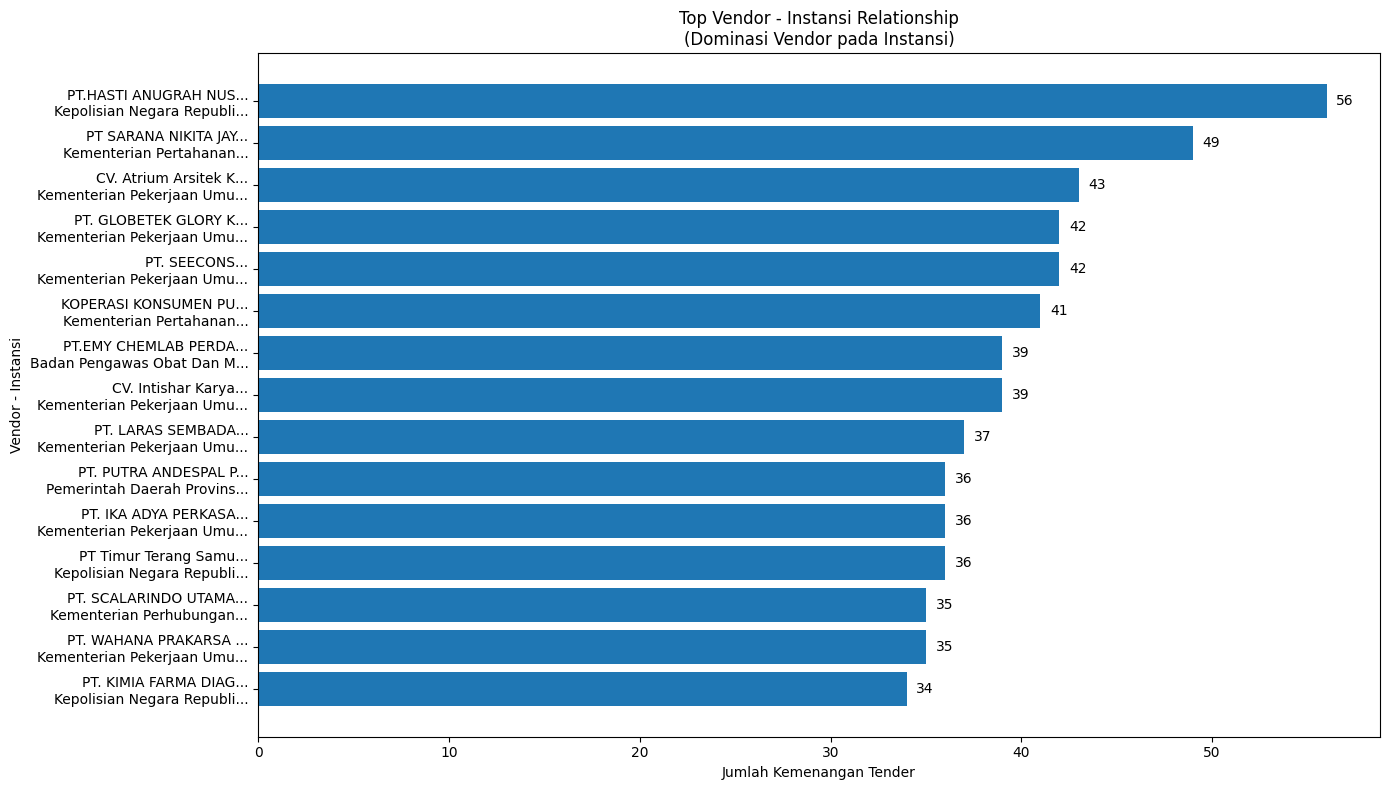

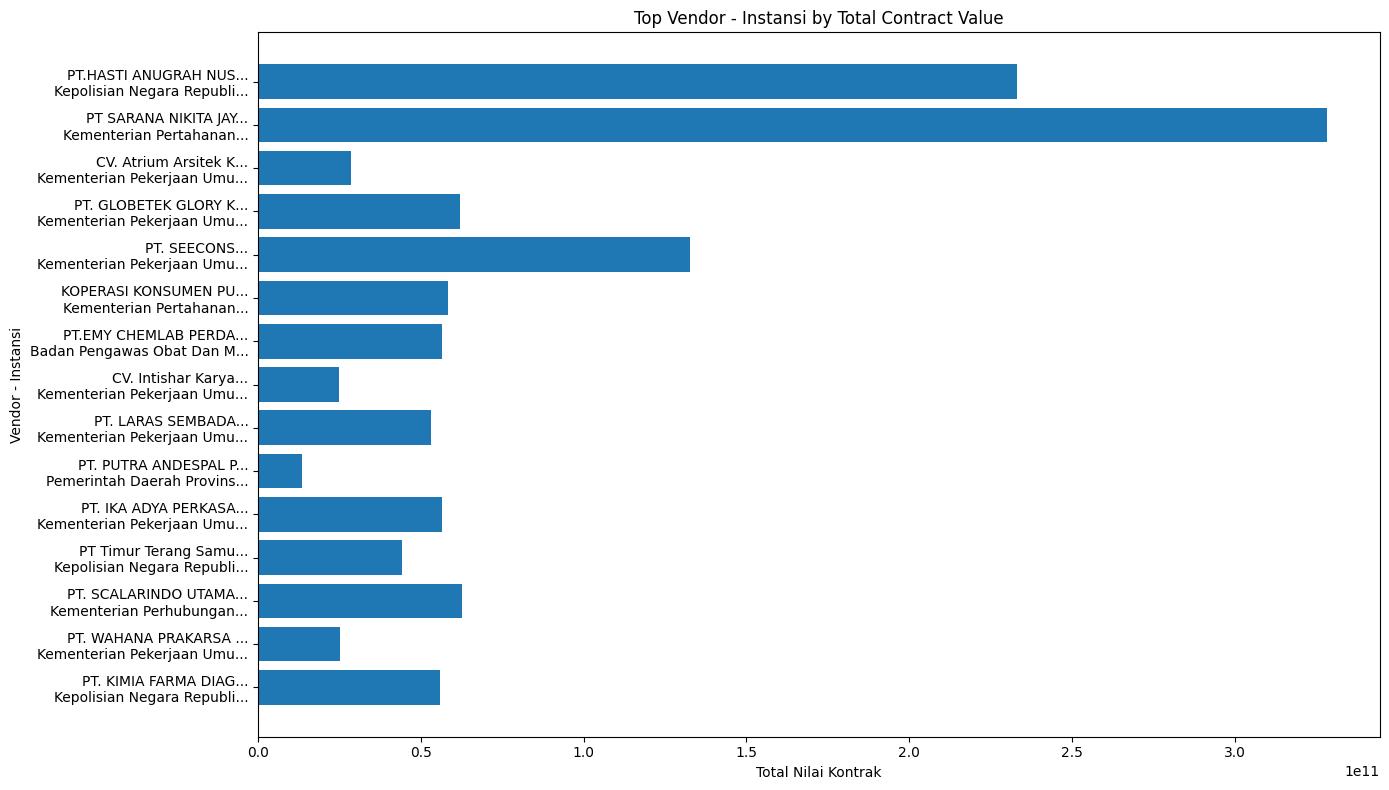


File berhasil disimpan:
top_vendor_buyer_relationship.csv


In [116]:
# ============================================================
# VISUALISASI TOP RELATIONSHIP VENDOR - INSTANSI
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. EXTRACT EDGE DATA DARI GRAPH
# ============================================================

edge_df = []

for u, v, d in G.edges(data=True):

    # ========================================================
    # IDENTIFIKASI MANA VENDOR & BUYER
    # ========================================================

    if u.startswith("V:"):
        vendor = u.replace("V: ", "")
        buyer  = v.replace("B: ", "")
    else:
        vendor = v.replace("V: ", "")
        buyer  = u.replace("B: ", "")

    # ========================================================
    # SIMPAN DATA
    # ========================================================

    edge_df.append({
        "vendor_name" : vendor,
        "buyer_name"  : buyer,
        "win_count"   : d["weight"],
        "total_value" : d["total_value"]
    })

# ============================================================
# 2. CONVERT KE DATAFRAME
# ============================================================

edge_df = pd.DataFrame(edge_df)

# ============================================================
# 3. SORT RELASI PALING DOMINAN
# ============================================================

top_edges = edge_df.sort_values(
    by="win_count",
    ascending=False
).head(15)

print("\nTOP RELATIONSHIP VENDOR - INSTANSI\n")
print(top_edges.to_string(index=False))

# ============================================================
# 4. BUAT LABEL
# ============================================================

labels = [
    f"{vendor[:20]}...\n{buyer[:25]}..."
    for vendor, buyer in zip(
        top_edges["vendor_name"],
        top_edges["buyer_name"]
    )
]

# ============================================================
# 5. VISUALISASI BAR CHART
# ============================================================

plt.figure(figsize=(14,8))

plt.barh(
    labels[::-1],
    top_edges["win_count"][::-1]
)

# ============================================================
# LABEL
# ============================================================

plt.xlabel("Jumlah Kemenangan Tender")
plt.ylabel("Vendor - Instansi")
plt.title(
    "Top Vendor - Instansi Relationship\n"
    "(Dominasi Vendor pada Instansi)"
)

# ============================================================
# TAMPILKAN ANGKA DI BAR
# ============================================================

for i, value in enumerate(top_edges["win_count"][::-1]):
    plt.text(
        value + 0.5,
        i,
        str(value),
        va='center'
    )

plt.tight_layout()
plt.show()

# ============================================================
# 6. VISUALISASI TOTAL NILAI KONTRAK
# ============================================================

plt.figure(figsize=(14,8))

plt.barh(
    labels[::-1],
    top_edges["total_value"][::-1]
)

plt.xlabel("Total Nilai Kontrak")
plt.ylabel("Vendor - Instansi")
plt.title(
    "Top Vendor - Instansi by Total Contract Value"
)

plt.tight_layout()
plt.show()

# ============================================================
# 7. SAVE RESULT
# ============================================================

top_edges.to_csv(
    "top_vendor_buyer_relationship.csv",
    index=False
)

print("\nFile berhasil disimpan:")
print("top_vendor_buyer_relationship.csv")

Preparing graph dataset...
Rows used : 20,000

Building graph...

GRAPH INFO
Nodes : 12394
Edges : 15803

Calculating centrality...

TOP CENTRAL VENDORS
                          vendor_name  degree_cent  betweenness_cent
10045             PT. Gumilang Sajati     0.000888          0.035465
4179             CV. KAISON KONSULTAN     0.000242          0.022157
10893      PT. TRIAS ERISKO KONSULTAN     0.000484          0.021233
9855      PT. DARMASRAYA MITRA AMERTA     0.000646          0.020655
8536                DELA CONCIETA. CV     0.000484          0.018731
6500                       CV. STB 64     0.000403          0.018195
10110      PT. INTIMULYA MULTIKENCANA     0.000565          0.018163
10444     PT. Munasa Kreasi Nusantara     0.000726          0.017839
9975   PT. GANESHA PRATAMA CONSULTANT     0.000968          0.016901
1398                 CV ZIDAN PRATAMA     0.000403          0.016485

Detecting exclusive vendors...
Exclusive vendors : 9149

Calculating buyer concentratio

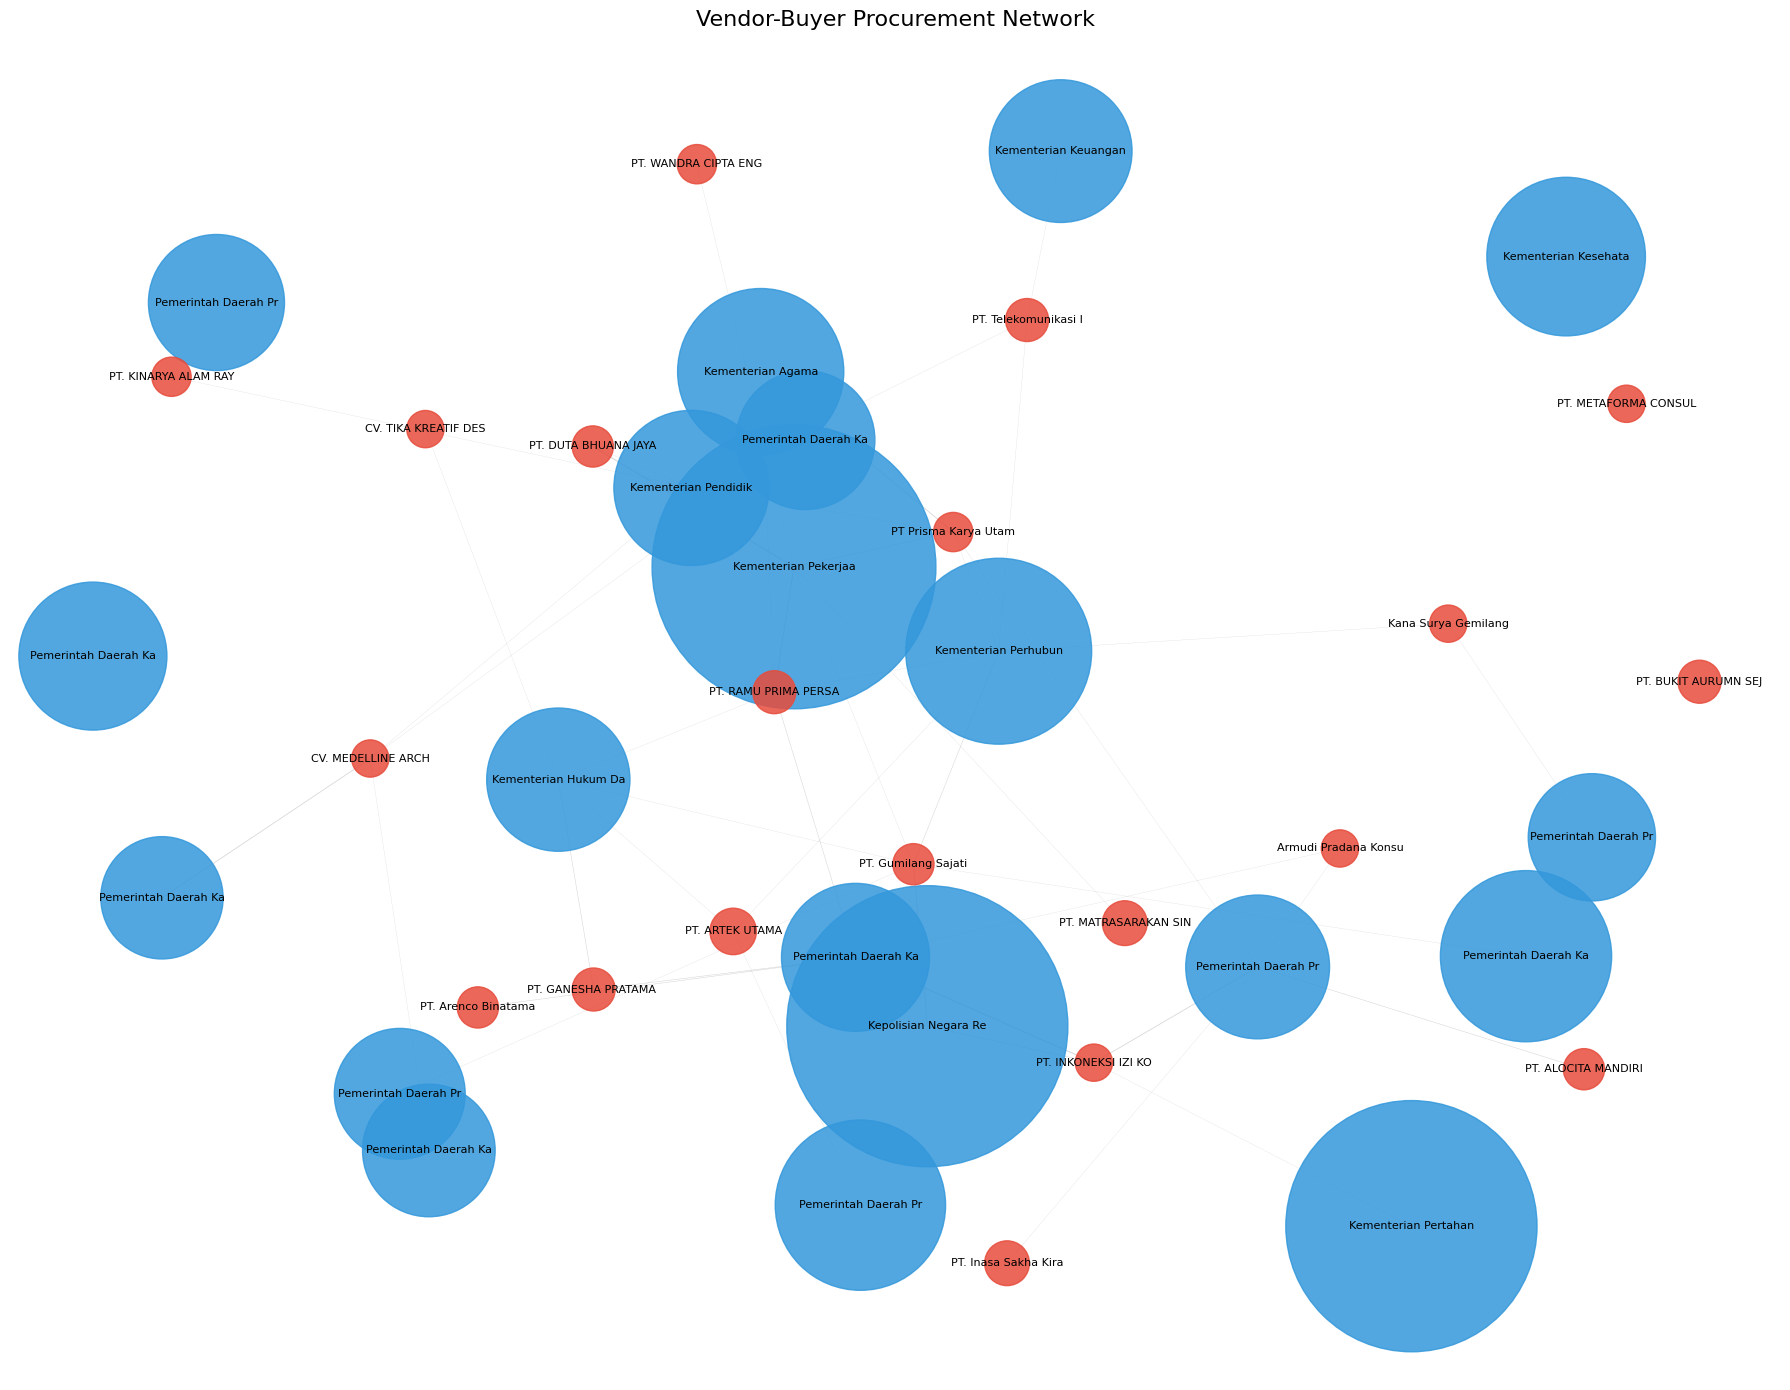


Generating interactive HTML graph...
Interactive HTML graph saved.


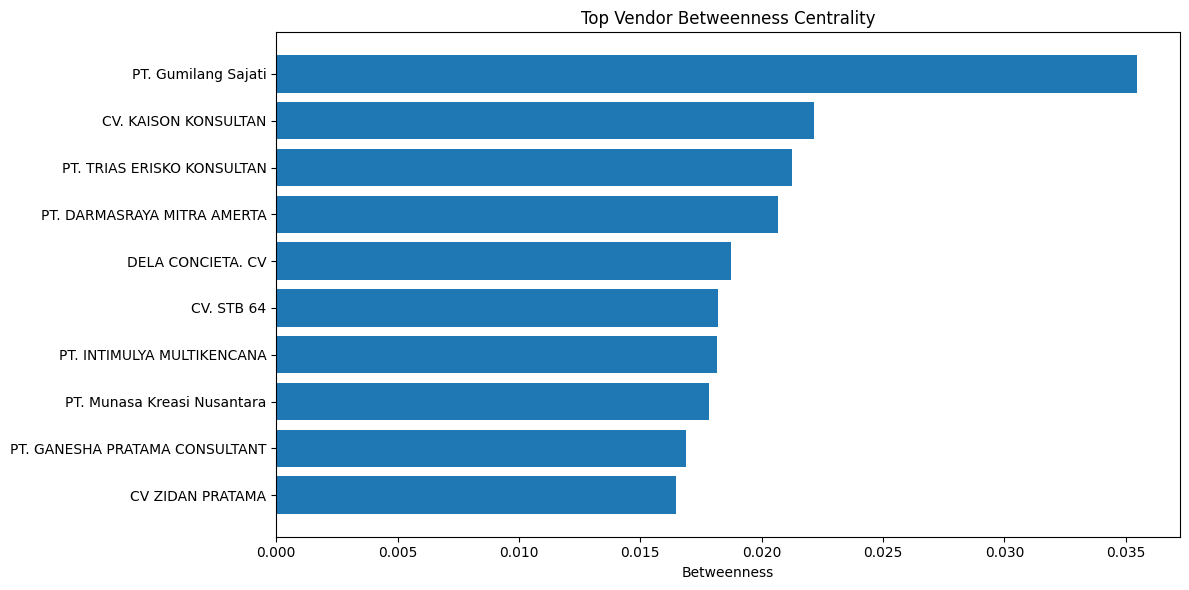

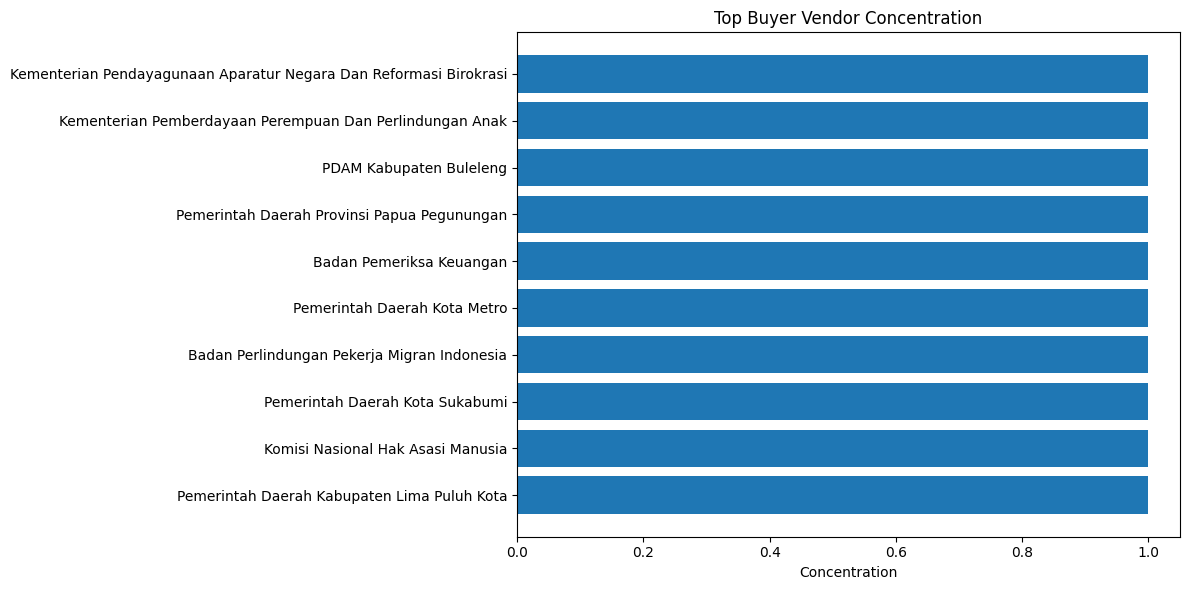


GRAPH ANALYSIS FINISHED
Generated files:
- optimized_graph_analysis.html
- graph_vendor_centrality.csv
- graph_buyer_risk.csv
- graph_exclusive_vendors.csv


: 

In [ ]:
# ============================================================
# OPTIMIZED GRAPH ANALYSIS
# PROCUREMENT FRAUD DETECTION SYSTEM
# FAST + CLEAN + STABLE VERSION
# ============================================================

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from pyvis.network import Network

# ============================================================
# 1. DATA PREPARATION
# ============================================================

print("Preparing graph dataset...")

# ------------------------------------------------------------
# DROP MISSING VALUES
# ------------------------------------------------------------

graph_df = df_data.dropna(
    subset=[
        "vendor_name",
        "buyer_name",
        "contract_value"
    ]
).copy()

# ------------------------------------------------------------
# FILTER VENDOR MINIMUM WIN
# ------------------------------------------------------------

MIN_VENDOR_WINS = 3

vendor_counts = graph_df["vendor_name"].value_counts()

valid_vendors = vendor_counts[
    vendor_counts >= MIN_VENDOR_WINS
].index

graph_df = graph_df[
    graph_df["vendor_name"].isin(valid_vendors)
]

# ------------------------------------------------------------
# OPTIONAL SAMPLING
# ------------------------------------------------------------

MAX_ROWS = 20000

if len(graph_df) > MAX_ROWS:

    graph_df = graph_df.sample(
        MAX_ROWS,
        random_state=42
    )

print(f"Rows used : {len(graph_df):,}")

# ============================================================
# 2. BUILD GRAPH (FAST)
# ============================================================

print("\nBuilding graph...")

G = nx.Graph()

# ------------------------------------------------------------
# GROUP DATA FIRST (MUCH FASTER)
# ------------------------------------------------------------

edge_df = (
    graph_df
    .groupby(
        ["vendor_name", "buyer_name"],
        as_index=False
    )
    .agg({
        "contract_value": "sum",
        "ocid": "count"
    })
    .rename(columns={
        "ocid": "weight"
    })
)

# ------------------------------------------------------------
# CREATE GRAPH
# ------------------------------------------------------------

for row in edge_df.itertuples(index=False):

    vendor = f"V: {row.vendor_name}"
    buyer  = f"B: {row.buyer_name}"

    G.add_node(vendor, node_type="vendor")
    G.add_node(buyer, node_type="buyer")

    G.add_edge(
        vendor,
        buyer,
        weight=row.weight,
        total_value=row.contract_value
    )

print("\n===================================")
print("GRAPH INFO")
print("===================================")

print("Nodes :", G.number_of_nodes())
print("Edges :", G.number_of_edges())

# ============================================================
# 3. CENTRALITY ANALYSIS
# ============================================================

print("\nCalculating centrality...")

# ------------------------------------------------------------
# FAST CENTRALITY
# ------------------------------------------------------------

degree_centrality = nx.degree_centrality(G)

# APPROXIMATE BETWEENNESS (MUCH FASTER)
betweenness_centrality = nx.betweenness_centrality(
    G,
    k=50,
    seed=42
)

# ============================================================
# 4. CENTRALITY DATAFRAME
# ============================================================

centrality_df = pd.DataFrame({

    "node": list(degree_centrality.keys()),

    "degree_cent": list(degree_centrality.values()),

    "betweenness_cent": [
        betweenness_centrality.get(n, 0)
        for n in degree_centrality.keys()
    ]
})

# ------------------------------------------------------------
# VENDOR ONLY
# ------------------------------------------------------------

vendor_centrality = centrality_df[
    centrality_df["node"].str.startswith("V:")
].copy()

vendor_centrality["vendor_name"] = (
    vendor_centrality["node"]
    .str.replace("V: ", "", regex=False)
)

vendor_centrality = vendor_centrality.sort_values(
    "betweenness_cent",
    ascending=False
)

print("\n===================================")
print("TOP CENTRAL VENDORS")
print("===================================")

print(
    vendor_centrality[
        [
            "vendor_name",
            "degree_cent",
            "betweenness_cent"
        ]
    ].head(10)
)

# ============================================================
# 5. EXCLUSIVE VENDOR DETECTION
# ============================================================

print("\nDetecting exclusive vendors...")

exclusive_vendors = []

for node in G.nodes():

    if node.startswith("V:"):

        neighbors = list(G.neighbors(node))

        if len(neighbors) == 1:

            buyer = neighbors[0]

            exclusive_vendors.append({

                "vendor_name":
                    node.replace("V: ", ""),

                "buyer_name":
                    buyer.replace("B: ", ""),

                "win_count":
                    G[node][buyer]["weight"],

                "total_value":
                    G[node][buyer]["total_value"]
            })

exclusive_df = pd.DataFrame(exclusive_vendors)

if not exclusive_df.empty:

    exclusive_df = exclusive_df.sort_values(
        "win_count",
        ascending=False
    )

print(f"Exclusive vendors : {len(exclusive_df)}")

# ============================================================
# 6. BUYER CONCENTRATION
# ============================================================

print("\nCalculating buyer concentration...")

buyer_risk = []

for node in G.nodes():

    if node.startswith("B:"):

        neighbors = list(G.neighbors(node))

        weights = [
            G[node][v]["weight"]
            for v in neighbors
        ]

        total_wins = sum(weights)

        max_wins = max(weights)

        top_vendor = neighbors[np.argmax(weights)]

        concentration = (
            max_wins / total_wins
            if total_wins > 0 else 0
        )

        buyer_risk.append({

            "buyer_name":
                node.replace("B: ", ""),

            "vendor_concentration":
                round(concentration, 3),

            "top_vendor":
                top_vendor.replace("V: ", ""),

            "top_vendor_wins":
                max_wins,

            "total_vendors":
                len(neighbors)
        })

buyer_risk_df = pd.DataFrame(buyer_risk)

buyer_risk_df = buyer_risk_df.sort_values(
    "vendor_concentration",
    ascending=False
)

print("\n===================================")
print("TOP BUYER CONCENTRATION")
print("===================================")

print(buyer_risk_df.head(10))

# ============================================================
# 7. EDGE RISK SCORE
# ============================================================

print("\nCalculating edge risk score...")

for u, v, d in G.edges(data=True):

    d["risk_score"] = (

        d["weight"] * 0.6

        +

        np.log1p(d["total_value"]) * 0.4
    )

# ============================================================
# 8. STATIC VISUALIZATION (BETTER)
# ============================================================

print("\nGenerating graph visualization...")

# ------------------------------------------------------------
# TOP BUYERS
# ------------------------------------------------------------

top_buyers = sorted(
    [n for n in G.nodes if n.startswith("B:")],
    key=lambda x: G.degree(x),
    reverse=True
)[:20]

# ------------------------------------------------------------
# TOP VENDORS
# ------------------------------------------------------------

top_vendors = sorted(
    [n for n in G.nodes if n.startswith("V:")],
    key=lambda x: G.degree(x),
    reverse=True
)[:20]

selected_nodes = top_buyers + top_vendors

subG = G.subgraph(selected_nodes)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(18, 14))

pos = nx.spring_layout(
    subG,
    k=0.7,
    seed=42
)

# ------------------------------------------------------------
# NODE COLORS
# ------------------------------------------------------------

node_colors = []

for n in subG.nodes():

    if n.startswith("V:"):
        node_colors.append("#e74c3c")
    else:
        node_colors.append("#3498db")

# ------------------------------------------------------------
# NODE SIZE
# ------------------------------------------------------------

node_sizes = [
    G.degree(n) * 80
    for n in subG.nodes()
]

# ------------------------------------------------------------
# DRAW NODES
# ------------------------------------------------------------

nx.draw_networkx_nodes(
    subG,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.85
)

# ------------------------------------------------------------
# DRAW EDGES
# ------------------------------------------------------------

edge_widths = []

for u, v in subG.edges():

    edge_widths.append(
        subG[u][v]["weight"] * 0.2
    )

nx.draw_networkx_edges(
    subG,
    pos,
    width=edge_widths,
    alpha=0.3,
    edge_color="gray"
)

# ------------------------------------------------------------
# LABELS
# ------------------------------------------------------------

labels = {
    n:
    n.replace("V: ", "")
     .replace("B: ", "")[:20]
    for n in subG.nodes()
}

nx.draw_networkx_labels(
    subG,
    pos,
    labels=labels,
    font_size=8
)

plt.title(
    "Vendor-Buyer Procurement Network",
    fontsize=16
)

plt.axis("off")

plt.tight_layout()

plt.show()

# ============================================================
# 9. PYVIS INTERACTIVE GRAPH
# ============================================================

print("\nGenerating interactive HTML graph...")

net = Network(
    height="850px",
    width="100%",
    bgcolor="#ffffff",
    font_color="black",
    notebook=False
)

net.from_nx(subG)

# ------------------------------------------------------------
# CUSTOM NODE STYLE
# ------------------------------------------------------------

for node in net.nodes:

    node_id = node["id"]

    is_vendor = node_id.startswith("V:")

    # COLOR
    node["color"] = (
        "#e74c3c"
        if is_vendor
        else "#3498db"
    )

    # SIZE
    node["size"] = (
        15
        +
        degree_centrality.get(node_id, 0) * 150
    )

    # LABEL
    node["label"] = (
        node_id
        .replace("V: ", "")
        .replace("B: ", "")
    )[:25]

    # TOOLTIP
    node["title"] = (
        f"""
        <b>{node['label']}</b><br>
        Degree: {degree_centrality.get(node_id,0):.4f}<br>
        Betweenness: {betweenness_centrality.get(node_id,0):.4f}
        """
    )

# ------------------------------------------------------------
# CUSTOM EDGE STYLE
# ------------------------------------------------------------

for edge in net.edges:

    edge["width"] = 1.5

    edge["color"] = "#bdc3c7"

# ------------------------------------------------------------
# PHYSICS
# ------------------------------------------------------------

net.set_options("""

var options = {

  "physics": {

    "barnesHut": {

      "gravitationalConstant": -1800,

      "centralGravity": 0.2,

      "springLength": 100

    },

    "minVelocity": 0.75
  }
}

""")

# ------------------------------------------------------------
# SAVE HTML
# ------------------------------------------------------------

net.write_html(
    "optimized_graph_analysis.html"
)

print("Interactive HTML graph saved.")

# ============================================================
# 10. VISUALIZATION
# ============================================================

# ------------------------------------------------------------
# TOP CENTRALITY
# ------------------------------------------------------------

top_cent = vendor_centrality.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_cent["vendor_name"][::-1],
    top_cent["betweenness_cent"][::-1]
)

plt.title(
    "Top Vendor Betweenness Centrality"
)

plt.xlabel("Betweenness")

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# BUYER CONCENTRATION
# ------------------------------------------------------------

top_buyers_plot = buyer_risk_df.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_buyers_plot["buyer_name"][::-1],
    top_buyers_plot["vendor_concentration"][::-1]
)

plt.title(
    "Top Buyer Vendor Concentration"
)

plt.xlabel("Concentration")

plt.tight_layout()

plt.show()

# ============================================================
# 11. EXPORT CSV
# ============================================================

vendor_centrality.to_csv(
    "graph_vendor_centrality.csv",
    index=False
)

buyer_risk_df.to_csv(
    "graph_buyer_risk.csv",
    index=False
)

exclusive_df.to_csv(
    "graph_exclusive_vendors.csv",
    index=False
)

print("\n===================================")
print("GRAPH ANALYSIS FINISHED")
print("===================================")

print("Generated files:")

print("- optimized_graph_analysis.html")
print("- graph_vendor_centrality.csv")
print("- graph_buyer_risk.csv")
print("- graph_exclusive_vendors.csv")